# Time-respecting paths, centralities and communities

*August 4 2026*  
*Training Workshop: Causality-Aware Temporal Networks*  
*Ingo Scholtes, CAIDAS, Julius-Maximilians-Universität Würzburg (JMU), Germany*  

In this notebook we will show how temporal network can be used to calculate (shortest) time respecting paths between nodes. We also show how we can assess temporal node centralities and temporal community structures.

In [ ]:
import pandas as pd

import pathpyG as pp

To illustrate time-respecting paths, we reuse the small example temporal graph from the previous notebook:

In [2]:
tedges = [('a', 'b', 1),('a', 'b', 2), ('b', 'a', 3), ('b', 'c', 3), ('d', 'c', 4), ('a', 'b', 4), ('c', 'b', 4),
              ('c', 'd', 5), ('b', 'a', 5), ('c', 'b', 6)]
t = pp.TemporalGraph.from_edge_list(tedges)
print(t)

Temporal Graph with 4 nodes, 6 unique edges and 10 events in [1, 6]
{'Edge Attributes': {}, 'Graph Attributes': {'num_nodes': "<class 'int'>"}, 'Node Attributes': {}}


We are often interested in time-respecting paths in a temporal graph. A time-respecting path consists of a sequence of nodes $v_0,...,v_l$ where consecutive nodes are connected by time-stamped edges that occur (i) in the right temporal ordering, and (ii) within a maximum time difference of $\delta\in \N$. 

To calculate time-respecting paths in a temporal graph, we can construct a directed acyclic graph (DAG), where each time-stamped edge $(u,v;t)$ in the temporal graph is represented by a node and two nodes representing time-stamped edges $(u,v;t_1)$ and $(v,w;t_2)$ are connected by an edge iff $0 < t_2-t_1 \leq \delta$. This implies that (i) each edge in the resulting DAG represents a time-respecting path of length two, and (ii) time-respecting paths of any lenghts are represented by paths in this DAG.

We can construct such a DAG using the function `pp.core.event_graph.EventGraph.build_edge_index`, which returns an edge_index. We can pass this to the constructor of a `Graph` object, which we can use to visualize the resulting DAG.

We call such a DAG a directed acyclic temporal event graph and we will cover it in more detail later in the tutorial.

In [3]:
e_i = pp.core.event_graph.EventGraph.build_edge_index(t, delta=1)
dag = pp.Graph.from_edge_index(e_i)
pp.plot(dag, node_label = [f'{v}-{w}-{time}' for v, w, time in t.temporal_edges]);

100%|██████████| 6/6 [00:00<00:00, 2182.83it/s]


For $\delta=1$, this DAG with three connected components tells us that the underlying temporal graph has  the following time-respecting paths (of different lengths):

Length one:  
    a -> b  
    b -> a  
    b -> c  
    c -> b  
    c -> d  
    d -> c  

Length two:  
    a -> b -> a (twice, starting at time 2 and time 4)  
    b -> a -> b  
    a -> b -> c     
    b -> c -> b  
    c -> b -> a  
    d -> c -> d  

Length three:   
    a -> b -> a -> b  
    b -> a -> b -> a  
    a -> b -> c -> b  
    b -> c -> b -> a  
    
Length four:   
    a -> b -> a -> b -> a  
    a -> b -> c -> b -> a  

We can can use the function `pp.algorithms.temporal.temporal_shortest_paths` to calculate shortest time-respecting path distances between any pair of nodes. This also returns a predecessor matrix, which can be used to reconstruct all shortest time-respecting paths (in analogy to the Dijkstra algorithm for static graphs):

In [4]:
dist, pred = pp.algorithms.temporal_shortest_paths(t, delta=1)
print(t.mapping)
print(dist)
print(pred)

100%|██████████| 6/6 [00:00<00:00, 2312.19it/s]


a -> 0
b -> 1
c -> 2
d -> 3

[[ 0.  1.  2. inf]
 [ 1.  0.  1. inf]
 [ 2.  1.  0.  1.]
 [inf inf  1.  0.]]
[[ 0  0  1 -1]
 [ 1  1  1 -1]
 [ 1  2  2  2]
 [-1 -1  3  3]]


In the example above, the four `inf` values indicate that there is no time-respecting paths between the four node pairs (a, d), (b, d), (d,a) and (d, b). This is not something we would expect based on the (strongly connected) topology of the time-aggregated graph, which is shown below:

In [5]:
g = t.to_static_graph(weighted=True)
pp.plot(g, node_label=g.mapping.node_ids.tolist());

`pathpyG`'s ability to calculate (shortest) time-respecting paths enables us to calulate different notions of temporal centralities for nodes in empirial temporal networks. We can read an empirical temporal graph based on CSV data, where each line contains the source, target, and timestamp of an edge as comma-separated value:

In [7]:
t_ants = pp.io.read_csv_temporal_graph('data/ants_1_1.tedges', header=False)
print(t_ants)

Temporal Graph with 89 nodes, 947 unique edges and 1911 events in [0, 1438]
{   'Edge Attributes': {'edge_attr_1': "<class 'torch.Tensor'> -> torch.Size([1911])", 'edge_attr_2': "<class 'torch.Tensor'> -> torch.Size([1911])"},
    'Graph Attributes': {'num_nodes': "<class 'int'>"},
    'Node Attributes': {}}


To calculate the temporal closeness centrality, which is defined based on the length of shortest time-respecting paths of a node to all other nodes, we can write the following: 

In [8]:
cl = pp.algorithms.centrality.temporal_closeness_centrality(t_ants, delta=60)
print(cl)
mx = max(cl.values())
mn = min(cl.values())
node_size = { v: 50*(x/(mx-mn)) for v, x in cl.items() }
pp.plot(t_ants, node_size=node_size, edge_color='red', edge_size=4);

100%|██████████| 883/883 [00:00<00:00, 3237.42it/s]


{'GBGR': 1855.3682539682543, 'GBGW': 2144.8952380952383, 'GBG_': 1926.2517704517697, 'GGGG': 1839.3590964590965, 'GGGR': 2224.5142857142864, 'GGRR': 3290.501587301587, 'GGRY': 2479.015873015873, 'GGWW': 2343.104761904761, 'GGWY': 4004.9111111111115, 'GGW_': 2800.495238095238, 'GGYW': 1928.7777777777771, 'GG_W': 2564.6761904761897, 'GRBR': 2094.504761904762, 'GRGY': 1884.3523809523801, 'GRWG': 2547.6000000000004, 'GRYY': 2001.3015873015868, 'GR_Y': 536.1714285714286, 'GR_Y2': 3647.3206349206357, 'GR__': 2167.8771672771677, 'GWRG': 2755.4825396825386, 'GYGG': 2220.219047619048, 'GYYY': 1278.2380952380952, 'GY__': 1401.8190476190482, 'G_GW': 2843.2380952380954, 'G_R_': 2072.0857142857144, 'G_W_': 2350.572405372405, 'G___': 2490.6095238095236, 'G___big': 909.2317460317461, 'G___small': 1365.7142857142862, 'Q': 3376.126984126984, 'RWGY': 2136.933333333333, 'RWWG': 2104.952380952381, 'WBGG': 2401.32380952381, 'WBGW': 2560.2095238095244, 'WBYG': 1891.8634920634925, 'WGBB': 2921.0761904761903,

The definition of time-respecting paths depends on our maximum time difference parameter $\delta$, which implies that different values of this parameter also yield different centralities. This means that we can calculate temporal node centralities for different "time scales" of a temporal graph.

In [9]:
cl = pp.algorithms.centrality.temporal_closeness_centrality(t_ants, delta=20)
print(cl)
mx = max(cl.values())
mn = min(cl.values())
node_size = { v: 50*(x/(mx-mn)) for v, x in cl.items() }
pp.plot(t_ants, node_size=node_size, edge_color='red', edge_size=4);

100%|██████████| 883/883 [00:00<00:00, 3049.33it/s]


{'GBGR': 948.9333333333333, 'GBGW': 825.7333333333333, 'GBG_': 1048.736507936508, 'GGGG': 909.3333333333334, 'GGGR': 1292.9714285714285, 'GGRR': 2549.82735042735, 'GGRY': 1403.4603174603174, 'GGWW': 1122.8380952380953, 'GGWY': 3188.533333333333, 'GGW_': 1704.2666666666669, 'GGYW': 963.6000000000001, 'GG_W': 1836.0920634920633, 'GRBR': 1427.1746031746031, 'GRGY': 579.3333333333334, 'GRWG': 1965.3333333333335, 'GRYY': 836.0, 'GR_Y': 259.6, 'GR_Y2': 2736.171428571429, 'GR__': 1230.5333333333333, 'GWRG': 1506.2666666666667, 'GYGG': 1132.2666666666667, 'GYYY': 482.53333333333336, 'GY__': 498.66666666666663, 'G_GW': 2114.3809523809523, 'G_R_': 973.8666666666668, 'G_W_': 1033.5809523809523, 'G___': 1180.0380952380954, 'G___big': 352.0, 'G___small': 440.0, 'Q': 2214.4984126984127, 'RWGY': 1100.0, 'RWWG': 1146.9333333333334, 'WBGG': 1479.8666666666668, 'WBGW': 1653.6666666666663, 'WBYG': 864.1809523809524, 'WGBB': 1567.2380952380952, 'WGGB': 1828.1999999999996, 'WGWB': 2168.2178266178266, 'WG_R

We can also calculate the temporal betweenness centrality, which is based on the number of shortest time-respecting paths between pairs of nodes that pass through a given node. Again, this centrality score is sensitive to the time scale parameter $\delta$.

In [10]:
bw = pp.algorithms.centrality.temporal_betweenness_centrality(t_ants, delta=60)
print(bw)
mx = max(bw.values())
mn = min(bw.values())
node_size = { v: 50*(x/(mx-mn)) for v, x in bw.items() }
pp.plot(t_ants, node_size=node_size, edge_color='red', edge_size=4);

100%|██████████| 86/86 [00:00<00:00, 150.32it/s]


defaultdict(<function temporal_betweenness_centrality.<locals>.<lambda> at 0x7c5993747380>, {'GBGR': 59.72162244296879, 'GR__': 48.672311418414786, 'YYRB': 70.7500296420718, 'GGWY': 1629.1673765136545, 'G_W_': 20.91666666666667, '_WYW': 823.7985830729975, '_W_Y': 200.22899089487356, 'Y___': 112.169752618089, '_WWW': 86.22215789354517, 'GGGR': 108.23114867158986, 'YGWY': 13.836110497502375, 'YGWW': 253.0977460598639, 'RWWG': 104.26446874788307, 'YY_R': 184.13884578780332, 'WRWR': 223.51768227026406, 'WYGG': 184.00017222368703, 'GGGG': 125.58964025663289, '____almost': 228.38574780855072, '____corner': 300.71942481896036, 'GGWW': 350.2723082617477, '_WYG': 154.6929371910979, 'GYGG': 245.0379200406802, 'YYGGright': 486.08600311447333, 'GRYY': 123.09709144397684, 'GR_Y2': 473.5143632815514, 'WWBG': 87.51891221523574, 'YYGW': 284.3556559059616, 'GGW_': 750.1521045976, 'WBGG': 105.66099701192513, 'YYGGmid': 445.6763903299383, 'WGBB': 124.14510550451729, 'G_R_': 126.40733594590536, 'YYGG': 64

In [11]:
bw = pp.algorithms.centrality.temporal_betweenness_centrality(t_ants, delta=20)
print(bw)
mx = max(bw.values())
mn = min(bw.values())
node_size = { v: 50*(x/(mx-mn)) for v, x in bw.items() }
pp.plot(t_ants, node_size=node_size, edge_color='red', edge_size=4);

100%|██████████| 86/86 [00:00<00:00, 1146.01it/s]


defaultdict(<function temporal_betweenness_centrality.<locals>.<lambda> at 0x7c5992437a60>, {'GBGR': 4.0, 'WGGB': 30.66666666666667, 'WBGW': 18.0, 'GR_Y2': 109.36666666666666, '_WWY': 66.33333333333336, '_R__': 175.83333333333326, 'YYGW': 76.0, 'YWW_': 5.0000000000000036, '_WYW': 98.58333333333334, 'WRRY': 40.5, 'Q': 289.49999999999994, 'GGWY': 465.45, 'YYRB': 5.0, '_W__': 21.999999999999996, 'GWRG': 13.500000000000002, '____pale': 61.83333333333336, 'YYGG': 148.33333333333334, 'WBGG': 17.833333333333336, '____brood': 22.249999999999996, 'GBGW': 11.666666666666666, '____bot': 7.0, 'GGRY': 64.16666666666669, 'YGWW': 150.33333333333317, 'YGWY': 11.0, 'YYWR': 39.833333333333336, 'WBYG': 33.33333333333333, 'GBG_': 50.08333333333333, 'GGYW': 2.5, 'GG_W': 51.25, 'WGWB': 74.95000000000002, 'GGGG': 36.533333333333324, '_W_Y': 60.70000000000001, 'G_W_': 13.0, 'GGW_': 156.16666666666663, 'WYGG': 71.76666666666668, 'GR__': 30.999999999999996, '____almost': 78.43333333333335, '_WYG': 26.5833333333

## Temporal vs. Static Centrality

How different are these temporal centralities from what we would get if we simply ignored the timing of interactions and computed standard centrality measures on the time-aggregated static graph? To find out, we compute the static closeness and betweenness centrality of the (weighted) time-aggregated ants network, and compare the top-10 ranked nodes to those obtained from the temporal centralities above ($\delta=60$).

In [ ]:
cl = pp.algorithms.centrality.temporal_closeness_centrality(t_ants, delta=60)
bw = pp.algorithms.centrality.temporal_betweenness_centrality(t_ants, delta=60)

g_ants = t_ants.to_static_graph(weighted=True)
static_cl = pp.algorithms.centrality.closeness_centrality(g_ants)
static_bw = pp.algorithms.centrality.betweenness_centrality(g_ants)

def top_k(centrality, k=10):
    """Return the k nodes with the highest centrality score."""
    return [node for node, _ in sorted(centrality.items(), key=lambda x: -x[1])[:k]]

top_temporal_cl = top_k(cl)
top_static_cl = top_k(static_cl)
top_temporal_bw = top_k(bw)
top_static_bw = top_k(static_bw)

print('Top-10 nodes by temporal closeness:  ', top_temporal_cl)
print('Top-10 nodes by static closeness:    ', top_static_cl)
print('Overlap:', len(set(top_temporal_cl) & set(top_static_cl)), '/ 10')
print()
print('Top-10 nodes by temporal betweenness:', top_temporal_bw)
print('Top-10 nodes by static betweenness:  ', top_static_bw)
print('Overlap:', len(set(top_temporal_bw) & set(top_static_bw)), '/ 10')

The rankings only partially agree. For closeness centrality, 8 of the top-10 nodes are shared between the temporal and static ranking, since closeness mainly reflects overall reachability, which is fairly robust to whether we account for time or not. For betweenness centrality, however, only half of the top-10 nodes agree: since betweenness depends on the exact set of shortest paths, and time-respecting paths can differ substantially from static shortest paths (recall the four `inf` entries we found earlier in our toy example), a node that appears to be an important "bridge" in the static topology may in fact rarely lie on an actual time-respecting path, and vice versa. This illustrates that ignoring the timing of interactions does not just add noise to centrality rankings, it can identify systematically different nodes as important.

## Visualizing Temporal Communities

Time-respecting paths also let us uncover **temporal communities**: groups of nodes that are connected by many time-respecting paths, even in cases where this pattern is not visible in the topology of the time-aggregated graph. This is exactly the same phenomenon that motivates the higher-order De Bruijn graph models used in the previous notebooks, but here we take a complementary, simulation-based perspective.

We load a synthetic temporal graph with 30 nodes and 60,000 time-stamped interactions, which was generated with a planted community structure (nodes 0-9, 10-19, and 20-29 each form a temporal community). Note that the CSV file uses the column names `source`, `target`, `time` instead of the `v`, `w`, `t` expected by `pp.io.read_csv_temporal_graph`, so we read it with `pandas` and rename the columns ourselves before converting it to a `TemporalGraph`:

In [12]:
df = pd.read_csv('data/temporal_clusters.tedges')
df.columns = ['v', 'w', 't']
t_clusters = pp.io.df_to_temporal_graph(df)
print(t_clusters)

Temporal Graph with 30 nodes, 557 unique edges and 60000 events in [0, 59999]
{'Edge Attributes': {}, 'Graph Attributes': {'num_nodes': "<class 'int'>"}, 'Node Attributes': {}}


We now simulate a random walker that takes time-respecting steps through this temporal graph. We repeatedly pick a random time-stamped edge $(u,v;t_1)$ as the first step of a walk. The walk can only continue to a second edge $(v,w;t_2)$ if it is time-respecting for $\delta=1$, i.e. if $0 < t_2-t_1 \leq \delta$. If a valid continuation exists, we have simulated a time-respecting walk of length two from $u$ to $w$, and we record this by incrementing the entry $(u,w)$ of a matrix $M$. Walks that cannot be continued are simply discarded. Repeating this many times and normalizing by the number of successful walks gives us a matrix whose entries capture how often pairs of nodes are connected by a time-respecting walk of length two.

In [13]:
import numpy as np

np.random.seed(0)

delta = 1
num_walks = 20000

# temporal_edges yields (v, w, time) tuples in temporal order
events = list(t_clusters.temporal_edges)

M = np.zeros((t_clusters.n, t_clusters.n))
num_successful = 0

for i in np.random.randint(0, len(events) - 1, size=num_walks):
    u, v, t1 = events[i]
    v2, w, t2 = events[i + 1]

    # the walk can only continue if the second edge starts where the first one ended
    # and is time-respecting for delta=1
    if v2 == v and 0 < (t2 - t1) <= delta:
        M[t_clusters.mapping.to_idx(u), t_clusters.mapping.to_idx(w)] += 1
        num_successful += 1

print(f'{num_successful} of {num_walks} simulated walks could be continued to length two')

10293 of 20000 simulated walks could be continued to length two


Let's plot the resulting matrix $M$, using the (numerical) node identifiers to order the rows and columns:

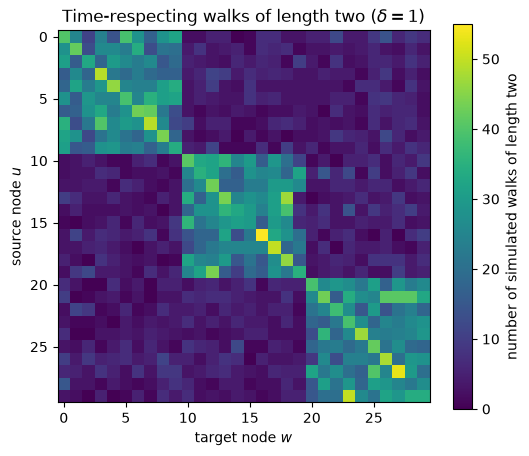

In [14]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 5))
plt.imshow(M, cmap='viridis')
plt.colorbar(label='number of simulated walks of length two')
plt.xlabel('target node $w$')
plt.ylabel('source node $u$')
plt.title(f'Time-respecting walks of length two ($\\delta={delta}$)')
plt.show()

Even though we never told the walker anything about node groups, three brighter blocks emerge along the diagonal of the matrix, corresponding exactly to the three planted communities (nodes 0-9, 10-19, and 20-29): time-respecting walks of length two much more frequently stay within one of these groups than they cross between groups. This is despite the fact that the topology of the time-aggregated graph itself does not show any such community structure (there is nothing special about the *static* connections between these nodes). The community structure only becomes visible once we take the temporal ordering of interactions into account, i.e. it is a genuinely **temporal-topological** pattern rather than a purely topological one.

For comparison, let's look at the same kind of matrix, but this time simply counting the number of (time-aggregated) edges between each pair of nodes, ignoring their timing entirely. We can obtain this using the `to_static_graph` function that we already used earlier in this notebook, which lets us access the edge counts as a weighted adjacency matrix:

In [ ]:
g_clusters = t_clusters.to_static_graph(weighted=True)
A = g_clusters.sparse_adj_matrix(edge_attr='edge_weight').todense()

plt.figure(figsize=(6, 5))
plt.imshow(A, cmap='viridis')
plt.colorbar(label='number of edges')
plt.xlabel('target node $w$')
plt.ylabel('source node $u$')
plt.title('Time-aggregated edge counts (static topology)')
plt.show()

Unlike the matrix of time-respecting walks of length two, the plain edge-count matrix shows no visible block structure: edges are essentially uniformly scattered across all pairs of nodes, regardless of community membership. This confirms that the community structure we found above is a genuinely temporal phenomenon: it is encoded in the *order* in which edges occur, not in *which* edges exist. A purely static analysis of this graph based on its edges alone would completely miss the three communities.